# House Price Prediction using Machine Learning

## Business Problem Statement

Accurately estimating house prices is a major challenge in the real estate industry. Property value depends on multiple factors such as location, size, quality, amenities, and overall condition.

A real estate company aims to build a data-driven machine learning model to predict house prices using historical housing data.

Incorrect pricing can lead to:

- Overpricing → Unsold properties and reduced competitiveness  
- Underpricing → Financial loss for sellers  
- Poor investment decisions for buyers and developers  

## Project Objective

- Develop a robust model to predict house sale prices  
- Identify key features influencing property value  
- Provide data-driven insights for better pricing decisions  

## Business Impact

The solution will help real estate agents, buyers, and developers make informed and competitive pricing decisions using analytical insights.

## Step 1: Data Understanding and Initial Exploration

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
data = pd.read_csv('data.csv')

In [4]:
data.head(5)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
data.shape

(1460, 81)

In [6]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [7]:
data.describe(include = 'all')

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
count,1460.000000,1460.000000,1460,1201.000000,1460.000000,1460,91,1460,1460,1460,...,1460.000000,7,281,54,1460.000000,1460.000000,1460.000000,1460,1460,1460.000000
unique,NaN,NaN,5,NaN,NaN,2,2,4,4,2,...,NaN,3,4,4,NaN,NaN,NaN,9,6,NaN
top,NaN,NaN,RL,NaN,NaN,Pave,Grvl,Reg,Lvl,AllPub,...,NaN,Gd,MnPrv,Shed,NaN,NaN,NaN,WD,Normal,NaN
freq,NaN,NaN,1151,NaN,NaN,1454,50,925,1311,1459,...,NaN,3,157,49,NaN,NaN,NaN,1267,1198,NaN
mean,730.500000,56.897260,NaN,70.049958,10516.828082,NaN,NaN,NaN,NaN,NaN,...,2.758904,NaN,NaN,NaN,43.489041,6.321918,2007.815753,NaN,NaN,180921.195890
std,421.610009,42.300571,NaN,24.284752,9981.264932,NaN,NaN,NaN,NaN,NaN,...,40.177307,NaN,NaN,NaN,496.123024,2.703626,1.328095,NaN,NaN,79442.502883
min,1.000000,20.000000,NaN,21.000000,1300.000000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,1.000000,2006.000000,NaN,NaN,34900.000000
25%,365.750000,20.000000,NaN,59.000000,7553.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,5.000000,2007.000000,NaN,NaN,129975.000000
50%,730.500000,50.000000,NaN,69.000000,9478.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,6.000000,2008.000000,NaN,NaN,163000.000000
75%,1095.250000,70.000000,NaN,80.000000,11601.500000,NaN,NaN,NaN,NaN,NaN,...,0.000000,NaN,NaN,NaN,0.000000,8.000000,2009.000000,NaN,NaN,214000.000000


### Data Understanding

The dataset contains **1460 records** and **81 features**, including both numerical and categorical variables.

- The target variable **SalePrice** has an average value of approximately **$180,921**, with prices ranging from **$34,900 to $755,000**, indicating high variation.
- Some features such as **LotFrontage, Alley, PoolQC, Fence, and MiscFeature** contain significant missing values.
- Most properties are in residential zoning (RL) and have paved street access.

Overall, the dataset requires proper handling of missing values and feature processing before model development.

## Step 2: Data Preprocessing and Cleaning

In [8]:
data.isnull().sum()

Id                 0
MSSubClass         0
MSZoning           0
LotFrontage      259
LotArea            0
                ... 
MoSold             0
YrSold             0
SaleType           0
SaleCondition      0
SalePrice          0
Length: 81, dtype: int64

In [9]:
pd.set_option('display.max_rows', None)
data.isnull().sum()              

Id                  0
MSSubClass          0
MSZoning            0
LotFrontage       259
LotArea             0
Street              0
Alley            1369
LotShape            0
LandContour         0
Utilities           0
LotConfig           0
LandSlope           0
Neighborhood        0
Condition1          0
Condition2          0
BldgType            0
HouseStyle          0
OverallQual         0
OverallCond         0
YearBuilt           0
YearRemodAdd        0
RoofStyle           0
RoofMatl            0
Exterior1st         0
Exterior2nd         0
MasVnrType        872
MasVnrArea          8
ExterQual           0
ExterCond           0
Foundation          0
BsmtQual           37
BsmtCond           37
BsmtExposure       38
BsmtFinType1       37
BsmtFinSF1          0
BsmtFinType2       38
BsmtFinSF2          0
BsmtUnfSF           0
TotalBsmtSF         0
Heating             0
HeatingQC           0
CentralAir          0
Electrical          1
1stFlrSF            0
2ndFlrSF            0
LowQualFin

### Missing Value Analysis

Several features contain missing values that require proper handling before model building.

- High missing values:
  - PoolQC (1453)
  - MiscFeature (1406)
  - Alley (1369)
  - Fence (1179)
  - MasVnrType (872)
  - FireplaceQu (690)

- Moderate missing values:
  - LotFrontage (259)
  - Garage-related features (81)
  - Basement-related features (~37–38)

Most missing values are related to optional house features (Pool, Fence, Alley, Fireplace), which likely indicate absence rather than data error.

Appropriate imputation or feature removal will be required during preprocessing.

<Axes: >

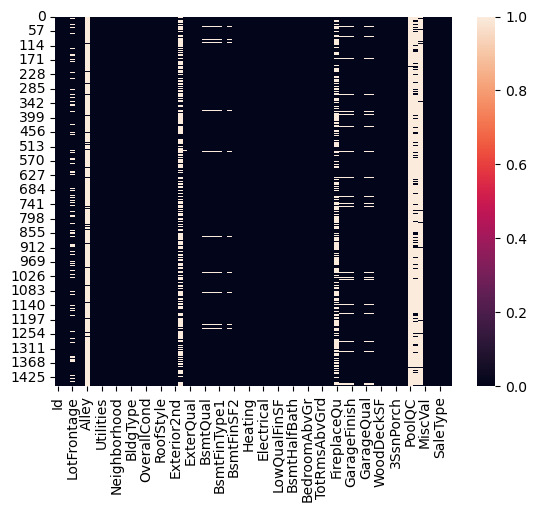

In [10]:
sns.heatmap(data.isnull())

In [11]:
missing_percent = data.isnull().sum() * 100 / len(data)
missing_percent

Id                0.000000
MSSubClass        0.000000
MSZoning          0.000000
LotFrontage      17.739726
LotArea           0.000000
Street            0.000000
Alley            93.767123
LotShape          0.000000
LandContour       0.000000
Utilities         0.000000
LotConfig         0.000000
LandSlope         0.000000
Neighborhood      0.000000
Condition1        0.000000
Condition2        0.000000
BldgType          0.000000
HouseStyle        0.000000
OverallQual       0.000000
OverallCond       0.000000
YearBuilt         0.000000
YearRemodAdd      0.000000
RoofStyle         0.000000
RoofMatl          0.000000
Exterior1st       0.000000
Exterior2nd       0.000000
MasVnrType       59.726027
MasVnrArea        0.547945
ExterQual         0.000000
ExterCond         0.000000
Foundation        0.000000
BsmtQual          2.534247
BsmtCond          2.534247
BsmtExposure      2.602740
BsmtFinType1      2.534247
BsmtFinSF1        0.000000
BsmtFinType2      2.602740
BsmtFinSF2        0.000000
B

In [12]:
data.drop(['Alley','PoolQC','Fence','MiscFeature'],axis = 1, inplace = True)

### Dropping High Missing Value Features

The features **Alley, PoolQC, Fence, and MiscFeature** were dropped because they contain extremely high percentages of missing values (above 80–95%).

Keeping these features may introduce noise and reduce model performance. Therefore, they are removed to simplify preprocessing and improve model stability.

In [13]:
missing_percent = data.isnull().sum() * 100 / len(data)
missing_percent.sort_values(ascending = False)

MasVnrType       59.726027
FireplaceQu      47.260274
LotFrontage      17.739726
GarageCond        5.547945
GarageYrBlt       5.547945
GarageFinish      5.547945
GarageQual        5.547945
GarageType        5.547945
BsmtFinType2      2.602740
BsmtExposure      2.602740
BsmtFinType1      2.534247
BsmtCond          2.534247
BsmtQual          2.534247
MasVnrArea        0.547945
Electrical        0.068493
BsmtFullBath      0.000000
Functional        0.000000
TotRmsAbvGrd      0.000000
GrLivArea         0.000000
HalfBath          0.000000
KitchenQual       0.000000
BedroomAbvGr      0.000000
FullBath          0.000000
KitchenAbvGr      0.000000
BsmtHalfBath      0.000000
Id                0.000000
Fireplaces        0.000000
ScreenPorch       0.000000
SaleCondition     0.000000
SaleType          0.000000
YrSold            0.000000
MoSold            0.000000
MiscVal           0.000000
PoolArea          0.000000
3SsnPorch         0.000000
2ndFlrSF          0.000000
EnclosedPorch     0.000000
O

In [14]:
data['LotFrontage'].unique()

array([ 65.,  80.,  68.,  60.,  84.,  85.,  75.,  nan,  51.,  50.,  70.,
        91.,  72.,  66., 101.,  57.,  44., 110.,  98.,  47., 108., 112.,
        74., 115.,  61.,  48.,  33.,  52., 100.,  24.,  89.,  63.,  76.,
        81.,  95.,  69.,  21.,  32.,  78., 121., 122.,  40., 105.,  73.,
        77.,  64.,  94.,  34.,  90.,  55.,  88.,  82.,  71., 120., 107.,
        92., 134.,  62.,  86., 141.,  97.,  54.,  41.,  79., 174.,  99.,
        67.,  83.,  43., 103.,  93.,  30., 129., 140.,  35.,  37., 118.,
        87., 116., 150., 111.,  49.,  96.,  59.,  36.,  56., 102.,  58.,
        38., 109., 130.,  53., 137.,  45., 106., 104.,  42.,  39., 144.,
       114., 128., 149., 313., 168., 182., 138., 160., 152., 124., 153.,
        46.])

<Axes: ylabel='LotFrontage'>

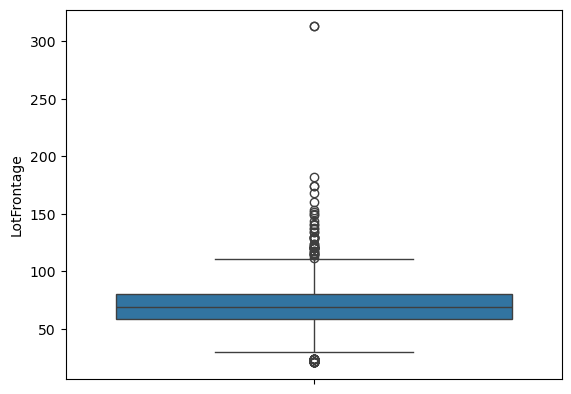

In [15]:
sns.boxplot(data['LotFrontage'])

### LotFrontage Outlier Analysis

- The boxplot shows that most properties have LotFrontage between 60–80 feet.

- However, several extreme outliers are observed (values above 150 and up to 313), which may distort model performance.

- Since LotFrontage also contains missing values, median imputation will be preferred as it is more robust to outliers compared to mean imputation.

In [16]:
data['LotFrontage'].fillna(data['LotFrontage'].median(),inplace = True)

In [17]:
data['GarageYrBlt'].unique()

array([2003., 1976., 2001., 1998., 2000., 1993., 2004., 1973., 1931.,
       1939., 1965., 2005., 1962., 2006., 1960., 1991., 1970., 1967.,
       1958., 1930., 2002., 1968., 2007., 2008., 1957., 1920., 1966.,
       1959., 1995., 1954., 1953.,   nan, 1983., 1977., 1997., 1985.,
       1963., 1981., 1964., 1999., 1935., 1990., 1945., 1987., 1989.,
       1915., 1956., 1948., 1974., 2009., 1950., 1961., 1921., 1900.,
       1979., 1951., 1969., 1936., 1975., 1971., 1923., 1984., 1926.,
       1955., 1986., 1988., 1916., 1932., 1972., 1918., 1980., 1924.,
       1996., 1940., 1949., 1994., 1910., 1978., 1982., 1992., 1925.,
       1941., 2010., 1927., 1947., 1937., 1942., 1938., 1952., 1928.,
       1922., 1934., 1906., 1914., 1946., 1908., 1929., 1933.])

In [18]:
data['YearBuilt'].unique()

array([2003, 1976, 2001, 1915, 2000, 1993, 2004, 1973, 1931, 1939, 1965,
       2005, 1962, 2006, 1960, 1929, 1970, 1967, 1958, 1930, 2002, 1968,
       2007, 1951, 1957, 1927, 1920, 1966, 1959, 1994, 1954, 1953, 1955,
       1983, 1975, 1997, 1934, 1963, 1981, 1964, 1999, 1972, 1921, 1945,
       1982, 1998, 1956, 1948, 1910, 1995, 1991, 2009, 1950, 1961, 1977,
       1985, 1979, 1885, 1919, 1990, 1969, 1935, 1988, 1971, 1952, 1936,
       1923, 1924, 1984, 1926, 1940, 1941, 1987, 1986, 2008, 1908, 1892,
       1916, 1932, 1918, 1912, 1947, 1925, 1900, 1980, 1989, 1992, 1949,
       1880, 1928, 1978, 1922, 1996, 2010, 1946, 1913, 1937, 1942, 1938,
       1974, 1893, 1914, 1906, 1890, 1898, 1904, 1882, 1875, 1911, 1917,
       1872, 1905], dtype=int64)

In [19]:
data['GarageYrBlt'].fillna(data['YearBuilt'],inplace = True)


### Handling Missing Values in GarageYrBlt

- The missing values in **GarageYrBlt** were replaced with the corresponding **YearBuilt** values.

- This assumption is reasonable because, in most cases, garages are constructed at the same time as the house. Filling missing values this way maintains logical consistency and avoids unnecessary data loss.

In [20]:
data['MasVnrArea'].unique()

array([1.960e+02, 0.000e+00, 1.620e+02, 3.500e+02, 1.860e+02, 2.400e+02,
       2.860e+02, 3.060e+02, 2.120e+02, 1.800e+02, 3.800e+02, 2.810e+02,
       6.400e+02, 2.000e+02, 2.460e+02, 1.320e+02, 6.500e+02, 1.010e+02,
       4.120e+02, 2.720e+02, 4.560e+02, 1.031e+03, 1.780e+02, 5.730e+02,
       3.440e+02, 2.870e+02, 1.670e+02, 1.115e+03, 4.000e+01, 1.040e+02,
       5.760e+02, 4.430e+02, 4.680e+02, 6.600e+01, 2.200e+01, 2.840e+02,
       7.600e+01, 2.030e+02, 6.800e+01, 1.830e+02, 4.800e+01, 2.800e+01,
       3.360e+02, 6.000e+02, 7.680e+02, 4.800e+02, 2.200e+02, 1.840e+02,
       1.129e+03, 1.160e+02, 1.350e+02, 2.660e+02, 8.500e+01, 3.090e+02,
       1.360e+02, 2.880e+02, 7.000e+01, 3.200e+02, 5.000e+01, 1.200e+02,
       4.360e+02, 2.520e+02, 8.400e+01, 6.640e+02, 2.260e+02, 3.000e+02,
       6.530e+02, 1.120e+02, 4.910e+02, 2.680e+02, 7.480e+02, 9.800e+01,
       2.750e+02, 1.380e+02, 2.050e+02, 2.620e+02, 1.280e+02, 2.600e+02,
       1.530e+02, 6.400e+01, 3.120e+02, 1.600e+01, 

<Axes: ylabel='MasVnrArea'>

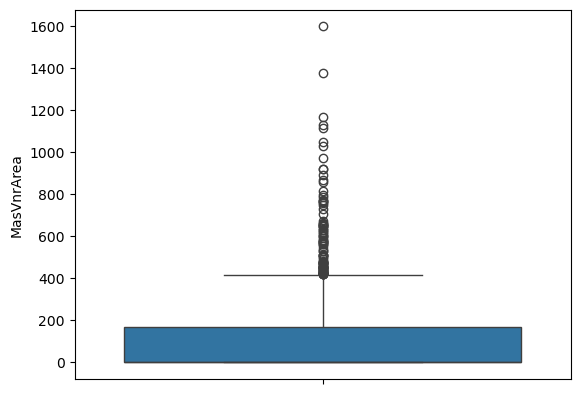

In [21]:
sns.boxplot(data['MasVnrArea'])

In [22]:
data['MasVnrArea'].fillna(data['MasVnrArea'].median(),inplace = True)

In [23]:
data['MasVnrType'].unique()

array(['BrkFace', nan, 'Stone', 'BrkCmn'], dtype=object)

In [24]:
data['BsmtQual'].unique()

array(['Gd', 'TA', 'Ex', nan, 'Fa'], dtype=object)

In [25]:
data['MasVnrType'].fillna('None', inplace=True)
data['BsmtQual'].fillna('None', inplace=True)
data['BsmtCond'].fillna('None', inplace=True)
data['BsmtExposure'].fillna('None', inplace=True)
data['BsmtFinType1'].fillna('None', inplace=True)
data['BsmtFinType2'].fillna('None', inplace=True)
data['FireplaceQu'].fillna('None', inplace=True)
data['GarageType'].fillna('None', inplace=True)
data['GarageFinish'].fillna('None', inplace=True)
data['GarageQual'].fillna('None', inplace=True)
data['GarageCond'].fillna('None', inplace=True)


### Handling Categorical Missing Values

- Missing values in basement, garage, masonry veneer, and fireplace-related features were replaced with **"None"**.

- These features represent optional house amenities. Therefore, missing values likely indicate the absence of that feature rather than missing data.

- Replacing NaN with "None" preserves information and ensures proper categorical encoding during model development.

In [26]:
data['Electrical'].unique()

array(['SBrkr', 'FuseF', 'FuseA', 'FuseP', 'Mix', nan], dtype=object)

In [27]:
data['Electrical'].fillna(data['Electrical'].mode(),inplace = True)

### Handling Missing Values in Electrical

- The missing value in the Electrical feature was replaced using the mode (most frequent category).

- Since Electrical is a categorical variable with only one missing value, mode imputation is appropriate and preserves the overall distribution of the feature.

In [28]:
data.isnull().sum()

Id               0
MSSubClass       0
MSZoning         0
LotFrontage      0
LotArea          0
Street           0
LotShape         0
LandContour      0
Utilities        0
LotConfig        0
LandSlope        0
Neighborhood     0
Condition1       0
Condition2       0
BldgType         0
HouseStyle       0
OverallQual      0
OverallCond      0
YearBuilt        0
YearRemodAdd     0
RoofStyle        0
RoofMatl         0
Exterior1st      0
Exterior2nd      0
MasVnrType       0
MasVnrArea       0
ExterQual        0
ExterCond        0
Foundation       0
BsmtQual         0
BsmtCond         0
BsmtExposure     0
BsmtFinType1     0
BsmtFinSF1       0
BsmtFinType2     0
BsmtFinSF2       0
BsmtUnfSF        0
TotalBsmtSF      0
Heating          0
HeatingQC        0
CentralAir       0
Electrical       1
1stFlrSF         0
2ndFlrSF         0
LowQualFinSF     0
GrLivArea        0
BsmtFullBath     0
BsmtHalfBath     0
FullBath         0
HalfBath         0
BedroomAbvGr     0
KitchenAbvGr     0
KitchenQual 

In [29]:
duplicate = data.duplicated().any()
duplicate

False

In [30]:
cat_cols = ['MSSubClass', 'MSZoning', 'Street', 'LotShape', 'LandContour',
            'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1',
            'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl',
            'Exterior1st', 'Exterior2nd', 'MasVnrType', 'ExterQual', 'ExterCond',
            'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1',
            'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical',
            'KitchenQual', 'Functional', 'FireplaceQu', 'GarageType',
            'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive',
            'SaleType', 'SaleCondition']

data[cat_cols] = data[cat_cols].astype('category')

### Converting Categorical Variables

- Selected categorical features were converted to the `category` data type. This improves memory efficiency and ensures proper handling during encoding (such as One-Hot Encoding) before model training.

In [31]:
data['GarageYrBlt'] = data['GarageYrBlt'].astype(int)

### Converting GarageYrBlt to Integer

- After handling missing values, the GarageYrBlt feature was converted to integer type. Since it represents a year value, integer format ensures correct numerical processing during model training.

In [32]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 77 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   Id             1460 non-null   int64   
 1   MSSubClass     1460 non-null   category
 2   MSZoning       1460 non-null   category
 3   LotFrontage    1460 non-null   float64 
 4   LotArea        1460 non-null   int64   
 5   Street         1460 non-null   category
 6   LotShape       1460 non-null   category
 7   LandContour    1460 non-null   category
 8   Utilities      1460 non-null   category
 9   LotConfig      1460 non-null   category
 10  LandSlope      1460 non-null   category
 11  Neighborhood   1460 non-null   category
 12  Condition1     1460 non-null   category
 13  Condition2     1460 non-null   category
 14  BldgType       1460 non-null   category
 15  HouseStyle     1460 non-null   category
 16  OverallQual    1460 non-null   int64   
 17  OverallCond    1460 non-null   in

In [33]:
data.drop('Id',axis = 1,inplace = True)

### Dropping Irrelevant Feature (Id)

- The `Id` column was removed because it is a unique identifier and does not contribute to predicting house prices. Keeping it may introduce unnecessary noise into the model.

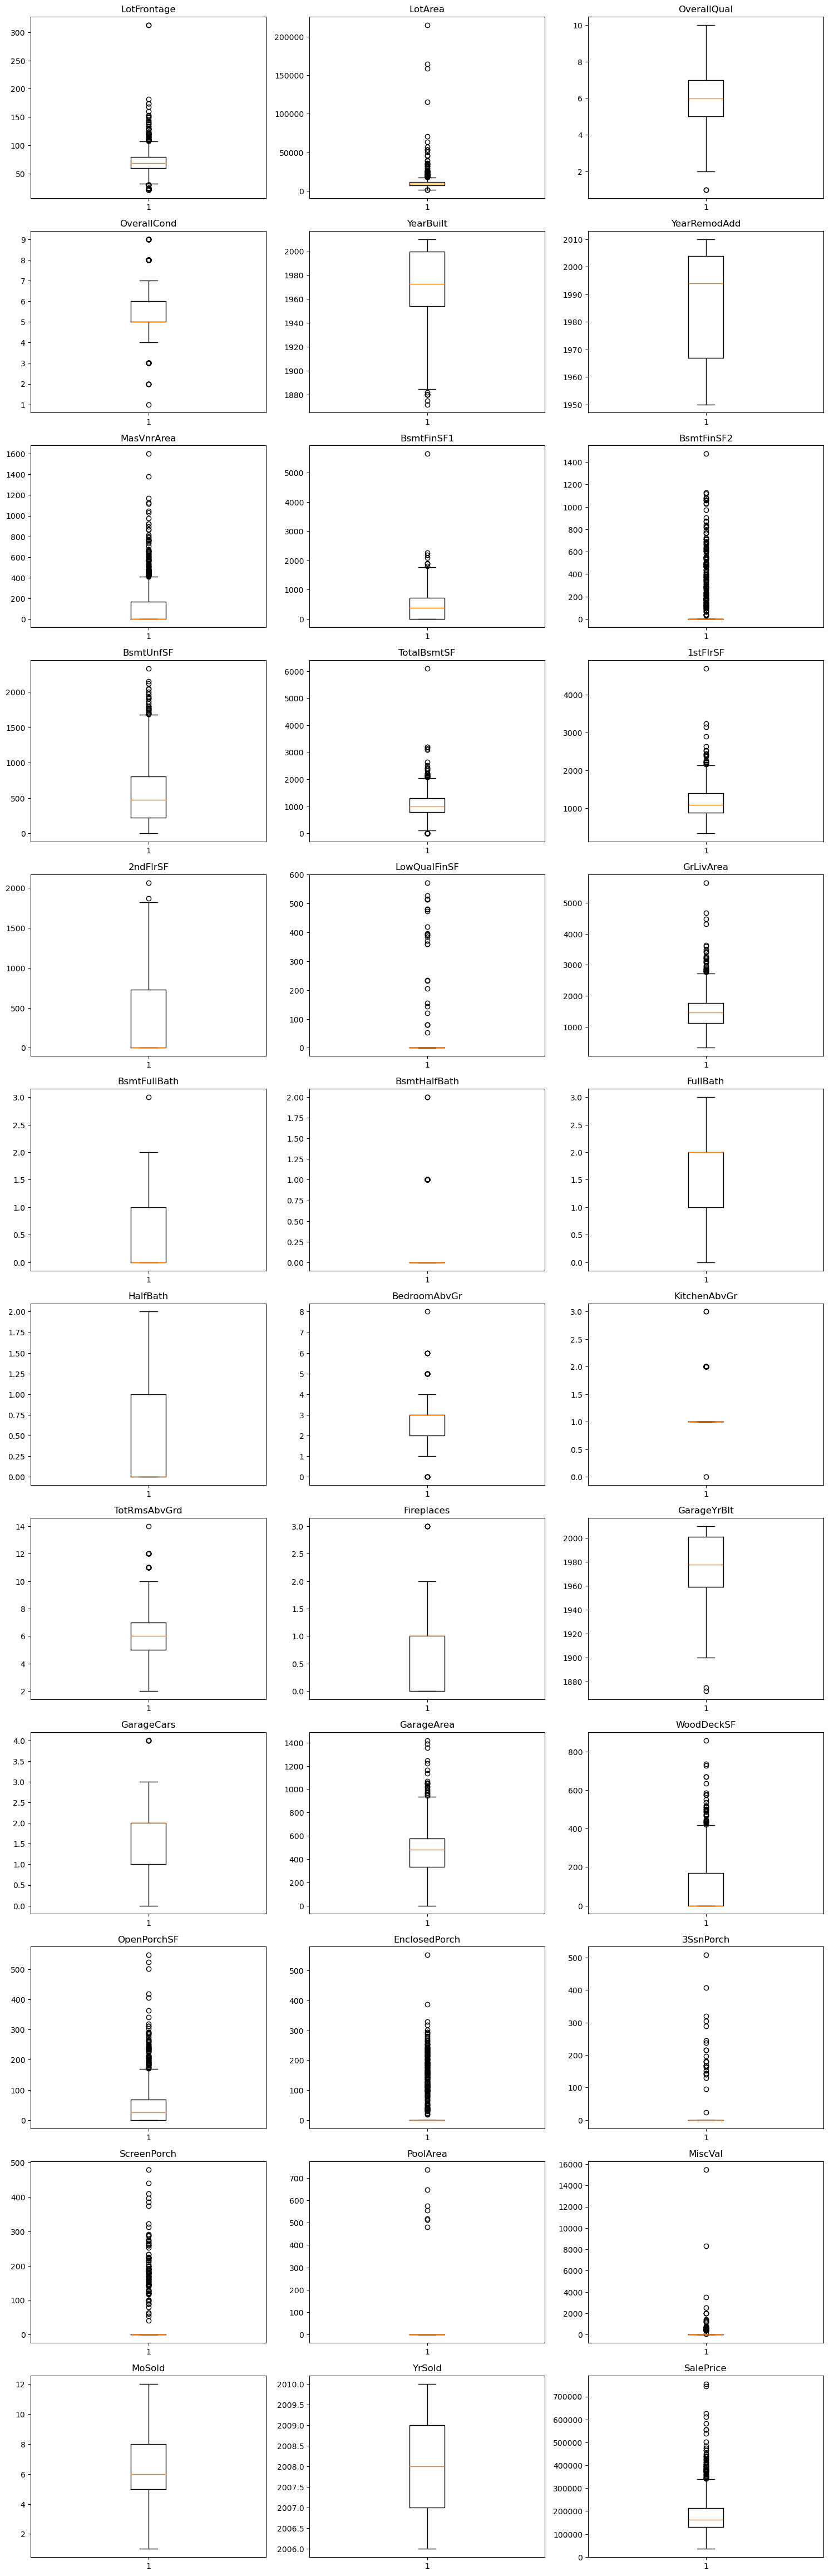

In [34]:
numeric_cols = data.select_dtypes(include = ['int64','int32','float64']).columns
plt.figure(figsize = (15,50))
for i, col in enumerate(numeric_cols,1):
    plt.subplot(len(numeric_cols)//3+1,3,i)
    plt.boxplot(x=data[col])
    plt.title(col)
plt.tight_layout()
plt.show()

In [35]:
outlier_cols = ['LotFrontage', 'LotArea', 'OverallCond', 'YearBuilt', 'MasVnrArea', 'BsmtFinSF1','BsmtFinSF2', 'BsmtUnfSF', 
                'TotalBsmtSF', '1stFlrSF', '2ndFlrSF', 'LowQualFinSF', 'GrLivArea', 'BsmtFullBath', 'BsmtHalfBath', 'BedroomAbvGr',
                'KitchenAbvGr', 'TotRmsAbvGrd', 'Fireplaces', 'GarageCars', 'GarageArea', 
                'WoodDeckSF', 'OpenPorchSF', 'EnclosedPorch', '3SsnPorch', 
                'ScreenPorch', 'PoolArea', 'MiscVal', 'SalePrice']

def cap_outliers(data, column):
    Q1 = data[column].quantile(0.25)
    Q3 = data[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - 1.5 * IQR
    upper_limit = Q3 + 1.5 * IQR

    data[column] = np.where(
        data[column] > upper_limit, upper_limit,
        np.where(data[column] < lower_limit, lower_limit, data[column])
    )

for col in outlier_cols:
    cap_outliers(data, col)


### Outlier Treatment using IQR Method

- Outliers were detected using the Interquartile Range (IQR) method and capped to the upper and lower limits. Instead of removing records, extreme values were winsorized (capped) to reduce their impact while preserving data. This helps improve model stability and prevents distortion in regression-based algorithms.

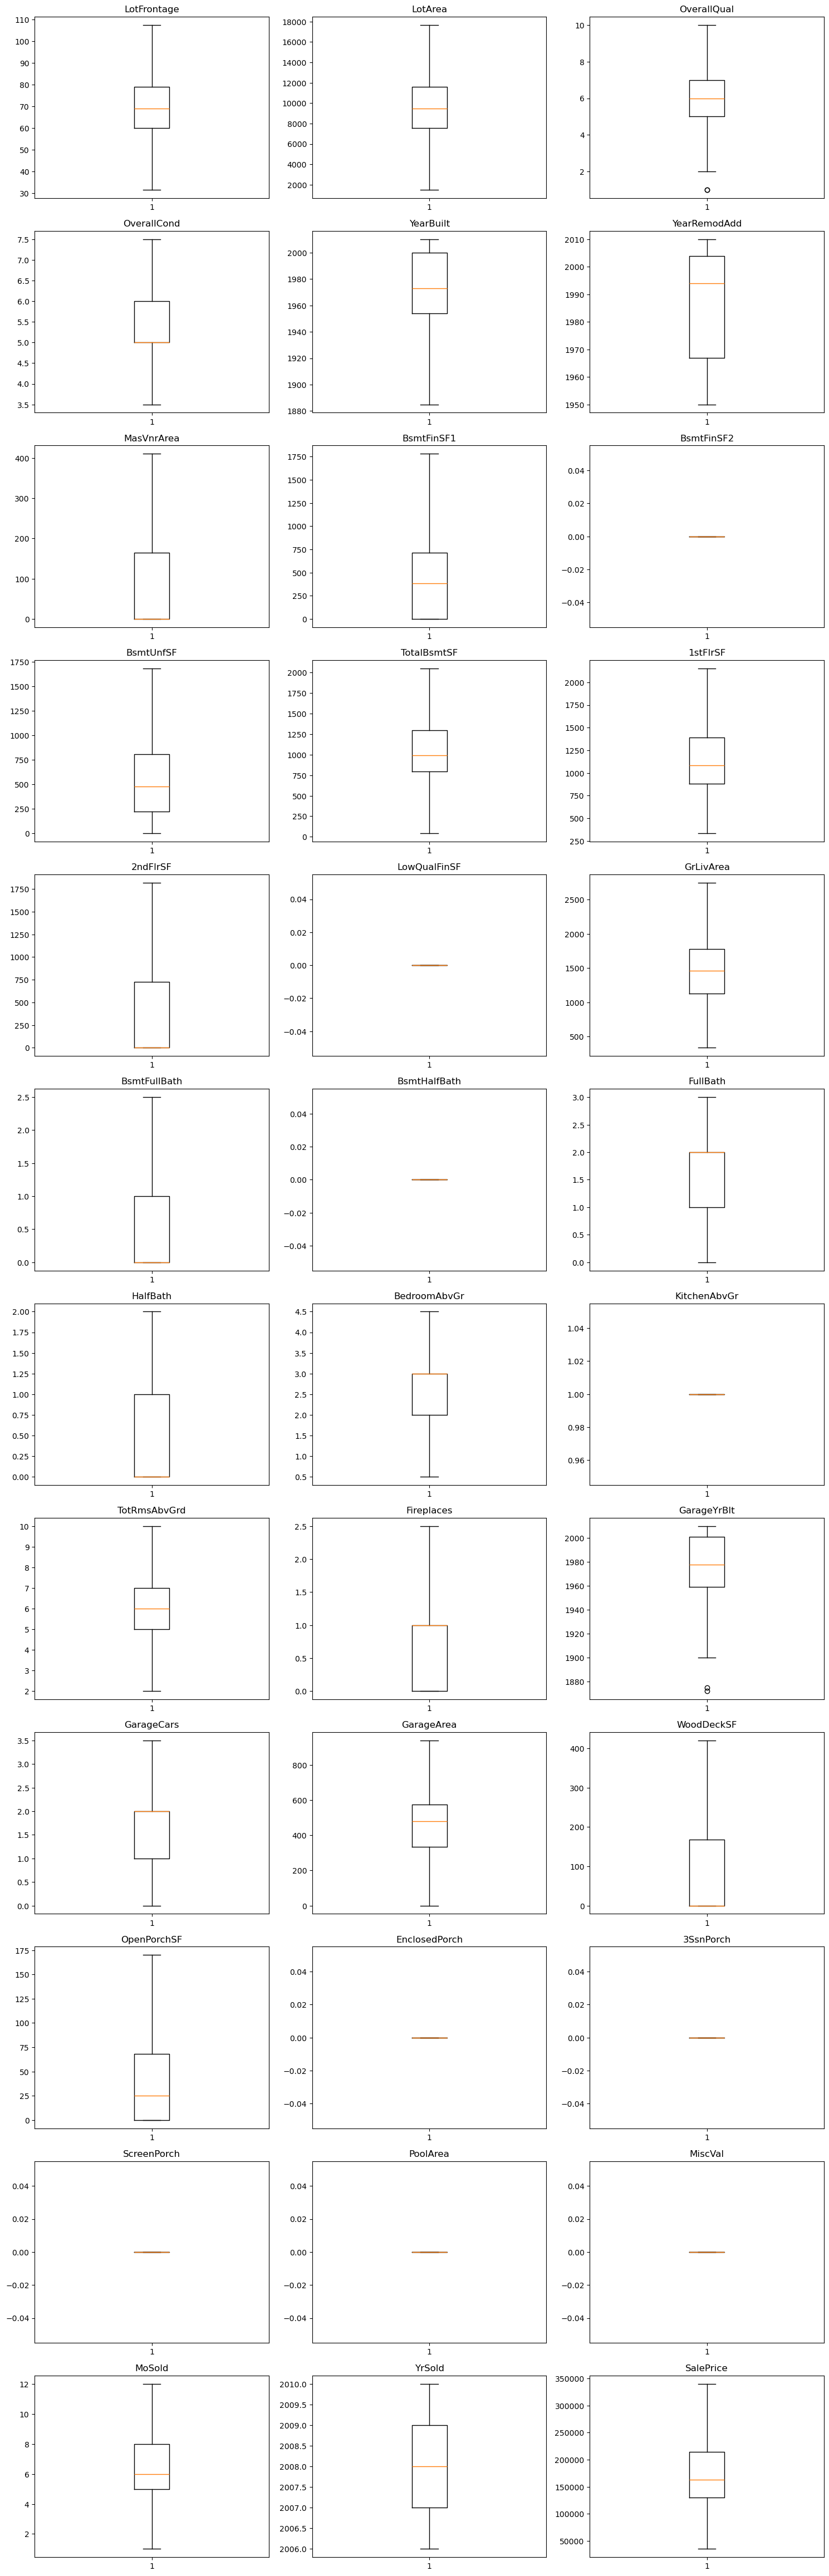

In [36]:
numeric_cols = data.select_dtypes(include = ['int64','int32','float64']).columns
plt.figure(figsize = (15,50))
for i, col in enumerate(numeric_cols,1):
    plt.subplot(len(numeric_cols)//3+1,3,i)
    plt.boxplot(x=data[col])
    plt.title(col)
plt.tight_layout()
plt.show()

### Outlier Treatment Result

- After applying the IQR capping method, extreme values have been controlled across numerical features. The distributions now appear more stable with reduced influence from extreme observations. This helps improve model performance and ensures more reliable regression results.

In [ ]:
from ydata_profiling import ProfileReport

In [ ]:
profile = ProfileReport(data, title = 'EDA', explorative = True)
profile

In [37]:
const_cols = ['BsmtFinSF2', 'LowQualFinSF', 'BsmtHalfBath', 'KitchenAbvGr',
              'EnclosedPorch', '3SsnPorch', 'ScreenPorch', 'PoolArea', 'MiscVal']
data.drop(columns = const_cols, inplace = True)


### Removing Constant Features

- The columns BsmtFinSF2, LowQualFinSF, BsmtHalfBath, KitchenAbvGr, EnclosedPorch, 3SsnPorch, ScreenPorch, PoolArea, and MiscVal were removed because they contained constant or near-constant values after preprocessing.

- Such features do not provide meaningful information for prediction and may unnecessarily increase model complexity.

In [ ]:
corr_matrix = data.corr(numeric_only=True)
plt.figure(figsize=(12, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", annot=False)
plt.title("Correlation Heatmap")
plt.show()

### Correlation Analysis

- The correlation heatmap shows that **OverallQual, GrLivArea, GarageCars, GarageArea, TotalBsmtSF, and 1stFlrSF** have strong positive correlation with SalePrice. This indicates that house quality, living area, garage capacity, and basement size significantly influence property prices.

- Some features also show multicollinearity (e.g., GarageCars & GarageArea, TotalBsmtSF & 1stFlrSF), which should be considered during model building.

In [ ]:
threshold = 0.8
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
high_corr = corr_pairs[(corr_pairs < 1.0) & (corr_pairs > threshold)]
print(high_corr)

In [ ]:
# dropping highly correlation
data.drop(['GarageCars', 'GarageYrBlt', 'TotRmsAbvGrd', 'TotalBsmtSF'], axis=1, inplace=True)


### Handling Multicollinearity

Highly correlated features were removed to reduce redundancy and multicollinearity.

From each highly correlated pair, one feature was dropped:

- GarageCars (retained GarageArea)
- GarageYrBlt (retained YearBuilt)
- TotRmsAbvGrd (retained GrLivArea)
- TotalBsmtSF (retained 1stFlrSF)

This helps improve model stability, especially for linear regression models.

In [ ]:
len(data.columns)

In [ ]:
# dropping imbalace column >90%
data.drop(['Utilities', 'Street', 'Condition2', 'RoofMatl', 'Heating'], axis=1,inplace = True)

### Removing Highly Imbalanced Features

- The features Utilities, Street, Condition2, RoofMatl, and Heating were removed because more than 90% of the observations belonged to a single category. Such highly imbalanced features provide very little predictive power and may not meaningfully contribute to the model. Removing them helps simplify the model and reduce unnecessary noise.

In [ ]:
len(data.columns)

In [ ]:
data.info()


## Step 3: Model Building and Training

In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression


In [ ]:
X = data.drop('SalePrice',axis = 1)
y = data['SalePrice']

In [ ]:
cat_cols = X.select_dtypes(include = ['category']).columns
num_cols = X.select_dtypes(include = ['int64','float64']).columns

In [ ]:
preprocessor = ColumnTransformer(
    transformers = [
        ('num','passthrough',num_cols),
        ('cat', OneHotEncoder(drop='first',handle_unknown='ignore'), cat_cols)
    ])

### Feature Preprocessing using ColumnTransformer

A ColumnTransformer was used to preprocess numerical and categorical features separately:

- Numerical features were passed through without transformation.
- Categorical features were encoded using One-Hot Encoding (with drop='first' to avoid multicollinearity).

This approach ensures proper preprocessing within a pipeline and prevents data leakage during model training.

In [ ]:
model = Pipeline(steps = [
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

### Building the Machine Learning Pipeline

A Pipeline was created by combining:

- The preprocessing step (ColumnTransformer)
- The Linear Regression model


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [ ]:
model.fit(X_train, y_train)

In [ ]:
y_pred = model.predict(X_test)

## Step 4: Model Evaluation and Comparison

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
    

In [ ]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

In [ ]:
print("Mean Absolute Error (MAE):", mae)
print("Mean Squared Error (MSE):", mse)
print("Root Mean Squared Error (RMSE):", rmse)
print("R² Score:", r2)

### Model Evaluation – Linear Regression

The Linear Regression model achieved:

- MAE: 15,296
- RMSE: 21,812
- R² Score: 0.90

An R² score of 0.90 indicates that the model explains approximately 90% of the variance in house prices.

The relatively low MAE and RMSE values suggest that the model predicts house prices with good accuracy. Overall, Linear Regression performs well on this dataset.

In [ ]:
plt.figure(figsize = (6,6))
plt.scatter(y_test, y_pred, alpha = 0.6)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.plot([y_test.min(),y_test.max()],[y_test.min(),y_test.max()],'r--')
plt.show()
           


### Actual vs Predicted Prices

- The scatter plot shows a strong linear relationship between actual and predicted house prices.

- Most data points lie close to the diagonal reference line, indicating that the model predictions are highly accurate. A few deviations are observed at higher price ranges, which is common in regression problems involving premium properties. Overall, the model demonstrates strong predictive performance.

In [ ]:
residuals = y_test - y_pred
plt.figure(figsize=(6,4))
plt.scatter(y_test, residuals, alpha=0.6)
plt.axhline(0, color='r', linestyle='--')
plt.xlabel("Actual Prices")
plt.ylabel("Residuals (Actual - Predicted)")
plt.title("Residuals Plot")
plt.show()


### Residual Analysis

- The residual plot shows that most residuals are randomly scattered around zero, indicating that the model captures the underlying pattern effectively.

- There is no strong systematic pattern, suggesting that linear regression assumptions are reasonably satisfied. However, slightly higher variance is observed for expensive houses, indicating minor heteroscedasticity at higher price ranges.

In [ ]:
from sklearn.linear_model import Ridge

ridge_model = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('regressor', Ridge(alpha=1.0))
])

ridge_model.fit(X_train, y_train)
y_pred_ridge = ridge_model.predict(X_test)

def evaluate_model(name, y_test, y_pred):
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    print(f"{name} Results:")
    print(f" MAE: {mae:.2f}")
    print(f" MSE: {mse:.2f}")
    print(f" RMSE: {rmse:.2f}")
    print(f" R²: {r2:.4f}")
    print("-" * 40)

evaluate_model("Linear Regression", y_test, y_pred)
evaluate_model("Ridge Regression", y_test, y_pred_ridge)


### Model Comparison – Linear vs Ridge Regression

- Ridge Regression slightly outperforms Linear Regression in terms of R² and RMSE, indicating better generalization by reducing multicollinearity through regularization.

- Although Linear Regression has slightly lower MAE, Ridge Regression provides more stable performance overall. Ridge Regression can be considered a better choice among the two.

In [ ]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
    ]
)

alphas = [0.001, 0.01, 0.1, 1, 10]
results = []

for alpha in alphas:
    model = Pipeline([
        ('preprocess', preprocessor),
        ('ridge', Ridge(alpha=alpha))
    ])

    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append((alpha, mae, mse, rmse, r2))

print("Ridge Regression Comparison:")
print("-" * 83)
for alpha, mae, mse, rmse, r2 in results:
    print(f"Alpha: {alpha:>6}, MAE: {mae:>10.2f}, MSE: {mse:>15.2f}, RMSE: {rmse:>10.2f}, R²: {r2:.4f}")


### Ridge Regression Tuning
Ridge Regression was tested with different alpha values.

Performance improved as alpha increased.  
The best result was achieved at **alpha = 10**:

- MAE: 14,447  
- RMSE: 20,362  
- R²: 0.9152  

Higher regularization helped reduce overfitting and improved model performance.

In [ ]:
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Keep only numeric features (same as before)
X_numeric = data.select_dtypes(include=['int64', 'float64']).drop(columns=['SalePrice'])
y = data['SalePrice']

# Split
X_train, X_test, y_train, y_test = train_test_split(X_numeric, y, test_size=0.2, random_state=42)

# Scale numeric columns
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Ridge Regression with alpha=10
ridge_final = Ridge(alpha=10)
ridge_final.fit(X_train_scaled, y_train)
y_pred = ridge_final.predict(X_test_scaled)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print(f"Ridge Regression (alpha=10)")
print(f"MAE: {mae:.2f}")
print(f"MSE: {mse:.2f}")
print(f"RMSE: {rmse:.2f}")
print(f"R²: {r2:.4f}")


In [ ]:

coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': ridge_final.coef_
}).sort_values(by='Coefficient', ascending=False)

print(coef_df.head(10))   # Top 10 features increasing price
print(coef_df.tail(10))   # Top 10 features decreasing price


In [ ]:
plt.figure(figsize=(8,6))
plt.barh(coef_df['Feature'][:10], coef_df['Coefficient'][:10])
plt.xlabel("Coefficient Value")
plt.title("Top 10 Features Influencing House Price")
plt.show()

### Top Features Influencing House Price

Based on Ridge Regression coefficients, the most important features increasing house price are:

- GrLivArea  
- OverallQual  
- YearBuilt  
- BsmtFinSF1  
- LotArea  

This indicates that larger living area, better overall quality, newer construction, and basement size significantly increase property value.

These insights help real estate stakeholders understand the key drivers of house pricing.

In [ ]:
numeric_data = data.select_dtypes(include=['int64', 'float64'])
plt.figure(figsize=(10,8))
sns.heatmap(numeric_data.corr()['SalePrice'].sort_values(ascending=False).to_frame(), annot=True, cmap='coolwarm')
plt.title("Correlation of Numeric Features with SalePrice")
plt.show()

### Correlation of Numeric Features with SalePrice

The strongest positive correlations with SalePrice are:

- OverallQual (0.82)
- GrLivArea (0.73)
- GarageArea (0.66)
- 1stFlrSF (0.62)
- FullBath (0.58)
- YearBuilt (0.57)

This indicates that overall quality, living area, garage size, floor area, and construction year significantly influence house prices.

Features such as YrSold and OverallCond show very weak or negative correlation, suggesting minimal direct impact on price.

In [ ]:
corr_with_target = numeric_data.corr()['SalePrice'].sort_values(ascending=False)
print(corr_with_target.head(10))

In [ ]:

y_pred = ridge_final.predict(X_test_scaled)

# Combine predictions with actual values
results = X_test.copy()
results['Actual_Price'] = y_test.values
results['Predicted_Price'] = y_pred

# Display few results
print("Sample Predictions:")
print(results[['Actual_Price', 'Predicted_Price']].head())

# Compare Actual vs Predicted prices
plt.figure(figsize=(6,6))
sns.scatterplot(x='Actual_Price', y='Predicted_Price', data=results, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted House Prices")
plt.show()

# Recommendation based on affordability
results['Price_Category'] = pd.qcut(results['Predicted_Price'], q=3, labels=['Low Budget', 'Mid Range', 'Luxury'])
print("\nPrice Category Counts:")
print(results['Price_Category'].value_counts())

# Suggest houses by area (if 'Neighborhood' exists)
if 'Neighborhood' in data.columns:
    area_avg = data.groupby('Neighborhood')['SalePrice'].mean().sort_values(ascending=False)
    plt.figure(figsize=(10,5))
    sns.barplot(x=area_avg.index, y=area_avg.values, palette='viridis')
    plt.xticks(rotation=90)
    plt.title("Average House Price by Neighborhood")
    plt.ylabel("Average Price")
    plt.show()

    print("\nTop 5 Expensive Areas:\n", area_avg.head())
    print("\nTop 5 Affordable Areas:\n", area_avg.tail())

# Analyze which features impact price most (using correlation)
corr = data.corr(numeric_only=True)['SalePrice'].sort_values(ascending=False)
print("\nTop Positive Correlations with SalePrice:\n", corr.head(10))
print("\nTop Negative Correlations with SalePrice:\n", corr.tail(10))

# Simple Feature Insight Plot
plt.figure(figsize=(8,5))
sns.barplot(x=corr.head(10).values, y=corr.head(10).index, palette='coolwarm')
plt.title("Top 10 Features Positively Correlated with House Price")
plt.xlabel("Correlation Coefficient")
plt.show()


### Final Conclusion

This project successfully developed a machine learning model to predict house prices using property features.

After preprocessing, feature engineering, multicollinearity handling, and regularization tuning, Ridge Regression (alpha = 10) achieved strong performance:

- R² Score: 0.91
- RMSE: 20,362
- MAE: 14,447

The model demonstrates strong generalization and reliable prediction capability.


### Key Insights

- OverallQual and GrLivArea are the strongest predictors of house price.
- GarageArea and 1stFlrSF significantly influence property valuation.
- Newer houses (YearBuilt, YearRemodAdd) tend to have higher prices.
- Neighborhood plays a major role in pricing variation.

Premium areas:
- NoRidge
- NridgHt
- StoneBr

Affordable areas:
- MeadowV
- IDOTRR
- BrDale


### Business Recommendations
- Buyers should focus on overall quality and living area when evaluating property value.
- Developers should invest in high-quality construction and larger usable space to maximize price.
- Real estate agents can use this model to set competitive listing prices.
- Investors can target premium neighborhoods for higher ROI.

The final model provides a data-driven pricing solution that improves decision-making in the real estate market.